In [1]:
import matplotlib.pyplot as plt
import numpy as np

from utils.fit_data import ResonanceFitData
from utils.pendulums_data import PendulumsData, prepare_data
from utils.plotting import add_resonance_plot_labels, plot_all, plot_each, save_plot

In [2]:
cols = ["mass A", "mass B", "mass C", "mass D"]
labels = ["97cm", "99cm", "99.5cm", "100cm"]
lengths = np.array([0.97, 0.99, 0.995, 1.0])
L_d = 0.99

In [3]:
pendulum_data = PendulumsData(
    cols=cols,
    labels=labels,
    lengths=lengths,
    data=prepare_data("../data/session-4/from5toEnd.csv", cols),
)

pendulum_data.preprocess_offsets()
pendulum_data.normalize()

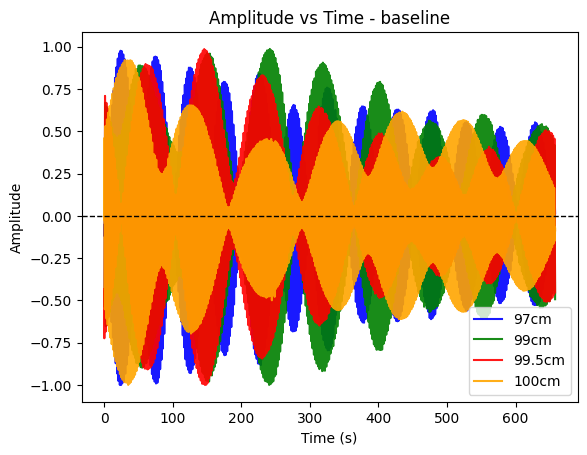

In [4]:
plot_all(pendulum_data, title="Amplitude vs Time - baseline")
save_plot("session-4/amp-vs-time-baseline-all.pdf")
plt.show()

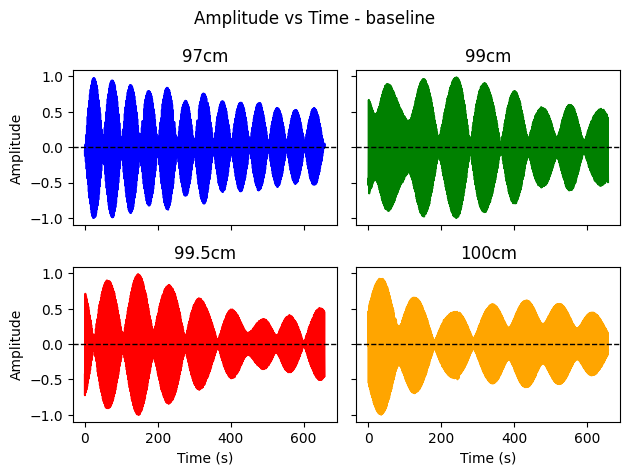

In [11]:
plot_each(pendulum_data, title="Amplitude vs Time - baseline")
save_plot("session-4/amp-vs-time-baseline-each.pdf")
plt.show()

In [6]:
resonance_data = ResonanceFitData(L_d, pendulum_data)

In [7]:
resonance_data.fit()
gamma, err = resonance_data.gamma, resonance_data.gamma_err

print(resonance_data.envelope_data)
print(f"Gamma: {gamma:.4f} ± {err:.4f}")

97cm: peaks=26; mean=0.728
99cm: peaks=17; mean=0.773
99.5cm: peaks=16; mean=0.636
100cm: peaks=15; mean=0.597
Gamma: 0.1119 ± 0.0746


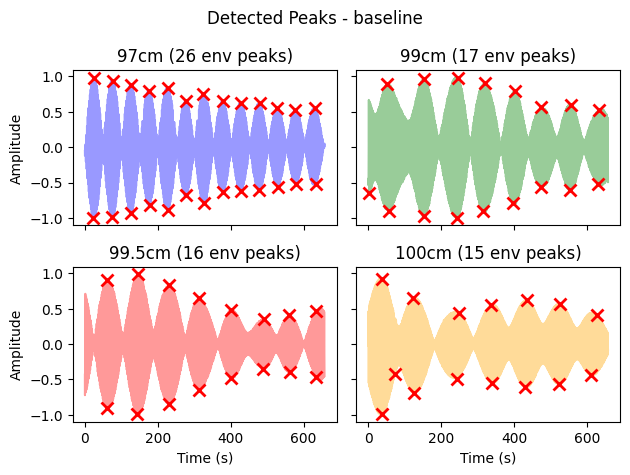

In [8]:
resonance_data.plot_detected_peaks(title="Detected Peaks - baseline")
save_plot("session-4/detected-peaks-baseline.pdf")
plt.show()

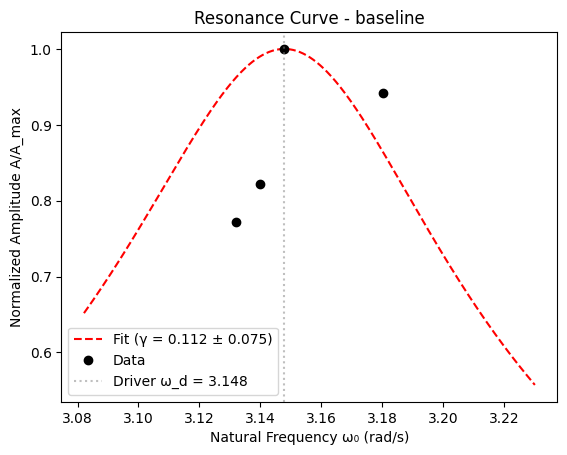

In [9]:
resonance_data.plot_resonance_curve("black", "red")

add_resonance_plot_labels(title="Resonance Curve - baseline")
save_plot("session-4/resonance-curve-baseline.pdf")
plt.show()